**Test Model**

In [1]:
import os
import dotenv
dotenv.load_dotenv()
import sys
sys.path.append(os.getenv('PROJECT_ROOT'))
from src.dataset import MRIDataset
from src.unet3d_dae import UNet3D
import torch
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(32)

##### 1.1 Data Preparation

In [2]:
# Define data path
t1_npz_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\IXI-T1')
t2_npz_dir = os.path.join(os.getenv('PROJECT_ROOT'), 'data\IXI-T2')

# Define dataset 
t1_dataset = MRIDataset(t1_npz_dir, 1)
t2_dataset = MRIDataset(t2_npz_dir, 2)

t1_dataset.files = t1_dataset.files[:300]
t2_dataset.files = t2_dataset.files[:300]

# Split sizes 
min_size = min(len(t1_dataset), len(t2_dataset))
train_size = int(0.7 * min_size)
val_size = int(0.15 * min_size)

# Create train, val, and test sets separately for T1 and T2
t1_train, t1_val, t1_test = random_split(t1_dataset, [train_size, val_size, len(t1_dataset) - train_size - val_size])
t2_train, t2_val, t2_test = random_split(t2_dataset, [train_size, val_size, len(t2_dataset) - train_size - val_size])

# Create DataLoaders
batch_size = 2
t1_test_loader = DataLoader(t1_test, batch_size=batch_size, shuffle=False)
t2_test_loader = DataLoader(t2_test, batch_size=batch_size, shuffle=False)

TypeError: listdir: path should be string, bytes, os.PathLike or None, not int

##### 1.2 Testing

In [6]:
# Custom MSE loss function with background exclusion
def masked_mse_loss(reconstructed, target, mask):
    masked_diff = (reconstructed - target) * mask 
    loss = torch.sum(masked_diff ** 2) / torch.sum(mask) 
    return loss

In [14]:
# Select device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model and move it to the selected device
model = UNet3D().to(device)
model.load_state_dict(torch.load(os.path.join(os.getenv('PROJECT_ROOT'), r'model\full_model_weights.pth'), weights_only=True, map_location=torch.device('cpu')))
model.eval()

UNet3D(
  (down1): DownBlock(
    (conv): ConvBlock(
      (conv1): WSConv3d(1, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (norm1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (film1): FiLM(
        (gamma): Linear(in_features=2, out_features=32, bias=True)
        (beta): Linear(in_features=2, out_features=32, bias=True)
      )
      (swish1): Swish()
      (conv2): WSConv3d(32, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (norm2): GroupNorm(8, 32, eps=1e-05, affine=True)
      (film2): FiLM(
        (gamma): Linear(in_features=2, out_features=32, bias=True)
        (beta): Linear(in_features=2, out_features=32, bias=True)
      )
      (swish2): Swish()
    )
    (pool): MaxPool3d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (down2): DownBlock(
    (conv): ConvBlock(
      (conv1): WSConv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
      (norm1): GroupNorm(8, 64, eps=1e-05, aff

In [16]:
# Initialize loss tracking
t1_test_losses = []
t1_test_loss_total = 0.0

t2_test_losses = []
t2_test_loss_total = 0.0

# Loop through testing dataset
for gt_1, ni_1, mask_1, mol_1 in t1_test_loader:
    gt_1, ni_1, mask_1, mol_1 = gt_1.to(device), ni_1.to(device), mask_1.to(device), mol_1.to(device)
    
    with torch.no_grad():
        output_1 = model(ni_1, mol_1)
        loss = masked_mse_loss(output_1, gt_1, mask_1)
    
    t1_test_losses.append(loss.item())
    t1_test_loss_total += loss.item()

for gt_2, ni_2, mask_2, mol_2 in t2_test_loader:
    gt_2, ni_2, mask_2, mol_2 = gt_2.to(device), ni_2.to(device), mask_2.to(device), mol_2.to(device)
    
    with torch.no_grad():
        output_2 = model(ni_2, mol_2)
        loss = masked_mse_loss(output_2, gt_2, mask_2)
    
    t2_test_losses.append(loss.item())
    t2_test_loss_total += loss.item()

# Compute average validation loss
t1_avg_val_loss = t1_test_loss_total / len(t1_test_loader)
t2_avg_val_loss = t2_test_loss_total / len(t2_test_loader)
print(f"Test Loss: T1: {t1_avg_val_loss:.6f}, T2: {t2_avg_val_loss:.6f}")

Test Loss: T1: 0.005146, T2: 0.006446


##### 1.3 Visualising

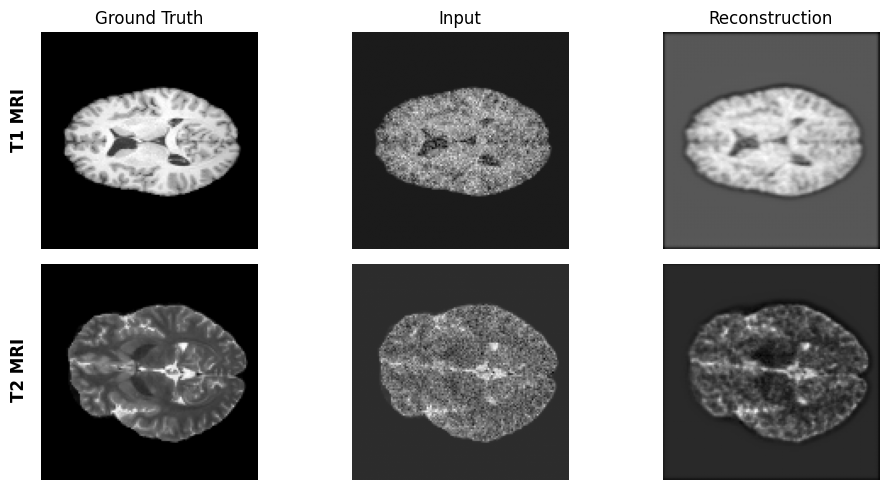

In [21]:
# Visualization of reconstructions 
t1_inputs_np = ni_1.cpu().numpy()
t1_recon_np = output_1.cpu().numpy()
t1_original_np = gt_1.cpu().numpy()

t2_inputs_np = ni_2.cpu().numpy()
t2_recon_np = output_2.cpu().numpy()
t2_original_np = gt_2.cpu().numpy()

# Create subplots with 2 rows (T1 and T2) and 3 columns (Ground Truth, Input, Reconstruction)
fig, axes = plt.subplots(2, 3, figsize=(10, 5))

# Select the first sample (index 0)
i = 0  

# Extract middle slices along depth
t1_ori_slice = t1_original_np[i, 0, :, :, t1_original_np.shape[-1] // 2]  
t1_mid_slice = t1_inputs_np[i, 0, :, :, t1_inputs_np.shape[-1] // 2]
t1_recon_slice = t1_recon_np[i, 0, :, :, t1_recon_np.shape[-1] // 2]

t2_ori_slice = t2_original_np[i, 0, :, :, t2_original_np.shape[-1] // 2]
t2_mid_slice = t2_inputs_np[i, 0, :, :, t2_inputs_np.shape[-1] // 2]
t2_recon_slice = t2_recon_np[i, 0, :, :, t2_recon_np.shape[-1] // 2]

# Plot T1 slices (row 0)
axes[0, 0].imshow(t1_ori_slice, cmap="gray")  
axes[0, 1].imshow(t1_mid_slice, cmap="gray")  
axes[0, 2].imshow(t1_recon_slice, cmap="gray")  

# Plot T2 slices (row 1)
axes[1, 0].imshow(t2_ori_slice, cmap="gray")  
axes[1, 1].imshow(t2_mid_slice, cmap="gray")  
axes[1, 2].imshow(t2_recon_slice, cmap="gray")  

# Remove axis labels
for row in range(2):
    for col in range(3):
        axes[row, col].axis("off")

# Set column titles
axes[0, 0].set_title("Ground Truth")
axes[0, 1].set_title("Input")
axes[0, 2].set_title("Reconstruction")

# Add row labels (T1 and T2) using fig.text()
fig.text(0.05, 0.75, "T1 MRI", fontsize=12, fontweight="bold", va="center", rotation=90)
fig.text(0.05, 0.25, "T2 MRI", fontsize=12, fontweight="bold", va="center", rotation=90)

plt.tight_layout()
plt.show()